In [1]:
# First I am importing the libraries I need

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Now I am loading the final sampled dataset

df = pd.read_csv("WC2026_Defenders_Final_Sample.csv")

# I am checking the first few rows
print(df.head())

   Rank             Player Position         Squad  Age  Born  90s  Tackles  \
0   928      Arthur Theate       DF       Belgium   26  2000  2.5        0   
1   966    Virgil van Dijk       DF   Netherlands   34  1991  4.3        1   
2   630       César Montes       DF        Mexico   29  1997  3.5        1   
3   427     Yasser Ibrahim       DF         Egypt   33  1993  5.2        6   
4   591  Mbekezeli Mbokazi       DF  South Africa   20  2005  4.0        5   

   Interceptions (Int) Tournament Stage  Interceptions per 90 mins  \
0                    3         Knockout                   1.200000   
1                    3         Knockout                   0.697674   
2                    2         Knockout                   0.571429   
3                    3         Knockout                   0.576923   
4                    4         Knockout                   1.000000   

  Eligible Defender FBref Player ID  
0               Yes        df8d6029  
1               Yes        e06683c

In [3]:
# I am separating the two groups so I can compare them

knockout = df[df["Tournament Stage"] == "Knockout"]

group_stage = df[
    df["Tournament Stage"] == "Group Stage Eliminated"
]

In [4]:
# I am checking the descriptive statistics for knockout-stage defenders

print("Knockout-stage defenders:")
print(knockout["Interceptions per 90 mins"].describe())

Knockout-stage defenders:
count    40.000000
mean      0.928111
std       0.532423
min       0.000000
25%       0.585407
50%       0.888938
75%       1.206122
max       2.222222
Name: Interceptions per 90 mins, dtype: float64


In [5]:
# Now I am checking the same statistics for group-stage eliminated defenders

print("Group-stage eliminated defenders:")
print(group_stage["Interceptions per 90 mins"].describe())

Group-stage eliminated defenders:
count    40.000000
mean      1.215229
std       0.702767
min       0.000000
25%       0.683908
50%       1.055556
75%       1.666667
max       3.666667
Name: Interceptions per 90 mins, dtype: float64


In [6]:
# I am creating a summary table so I can compare both groups more easily

summary = df.groupby("Tournament Stage")["Interceptions per 90 mins"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

print(summary)

                        count      mean    median       std  min       max
Tournament Stage                                                          
Group Stage Eliminated     40  1.215229  1.055556  0.702767  0.0  3.666667
Knockout                   40  0.928111  0.888938  0.532423  0.0  2.222222


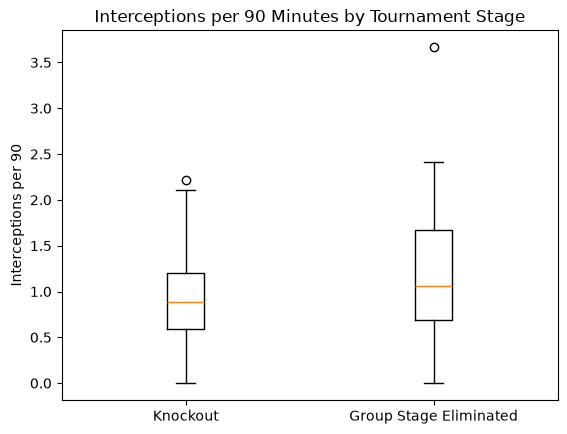

In [7]:
# I am creating a boxplot to visually compare interceptions per 90
# between the two tournament groups

data_to_plot = [
    knockout["Interceptions per 90 mins"],
    group_stage["Interceptions per 90 mins"]
]

plt.boxplot(
    data_to_plot,
    tick_labels=["Knockout", "Group Stage Eliminated"]
)

plt.title("Interceptions per 90 Minutes by Tournament Stage")
plt.ylabel("Interceptions per 90")
plt.show()

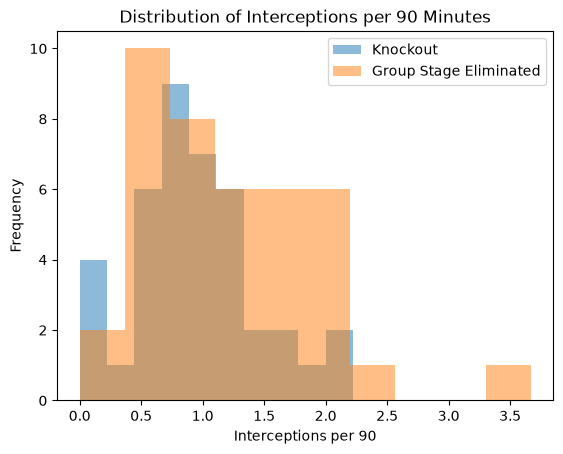

In [8]:
# I am using a histogram to look at the distribution of interceptions per 90
# in both groups

plt.hist(
    knockout["Interceptions per 90 mins"],
    alpha=0.5,
    label="Knockout"
)

plt.hist(
    group_stage["Interceptions per 90 mins"],
    alpha=0.5,
    label="Group Stage Eliminated"
)

plt.title("Distribution of Interceptions per 90 Minutes")
plt.xlabel("Interceptions per 90")
plt.ylabel("Frequency")
plt.legend()
plt.show()